In [1]:
import torch
import random
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

In [2]:
# ---------------------------------------------------------------------------*/
# - prepare a dataset

# define known data properties
timeseries_len = 351
timestep = 0.02

dataset_dir = 'pendulum_1rad_10rad_T351'

# read training data from a file
data_train = utils.read_datafile(f'{dataset_dir}/train6', timeseries_len)
data_ch_n = data_train.shape[-1]
print(f"inf >> Training data consists of {data_train.shape[0]} batches, where each batch has {data_train.shape[2]} data channels and {data_train.shape[1]} time steps")

# read validation data from file
data_valid = utils.read_datafile(f'{dataset_dir}/valid', timeseries_len)
print(f"inf >> Validation data consists of {data_valid.shape[0]} batches, where each batch has {data_valid.shape[2]} data channels and {data_valid.shape[1]} time steps")

# read test data from file
data_test = utils.read_datafile(f'{dataset_dir}/test', timeseries_len)
print(f"inf >> Test data consists of {data_test.shape[0]} batches, where each batch has {data_test.shape[2]} data channels and {data_test.shape[1]} time steps")


inf >> Training data consists of 3500 batches, where each batch has 2 data channels and 351 time steps
inf >> Validation data consists of 1000 batches, where each batch has 2 data channels and 351 time steps
inf >> Test data consists of 500 batches, where each batch has 2 data channels and 351 time steps


In [3]:
# ---------------------------------------------------------------------------*/
# - instantiate dynamic mode decomposition

config = {
    'data_ch_n'              : data_ch_n,
    'modes'                  : [(1., 0.1), (10., 0.1)],
    'timestep'               : timestep,
    'horizon'                : 351,
    'batch_size'             : 64,
    'loss_hp_pred'           : 1e1,
    'loss_hp_recon'          : 1e0,
    'loss_hp_mode'           : 1e-1,
    'loss_hp_sparse_weights' : 0,
    'loss_hp_big_weights'    : 1e-6
}

model = care.dmd(config)

inf >> Number of data files for training : 4
inf >> Processing training file number 1
inf >> Processing training file number 2
inf >> Processing training file number 3
inf >> Processing training file number 4


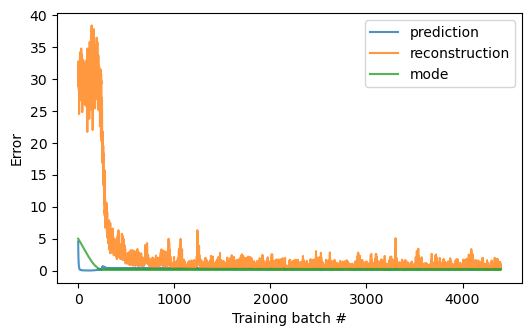

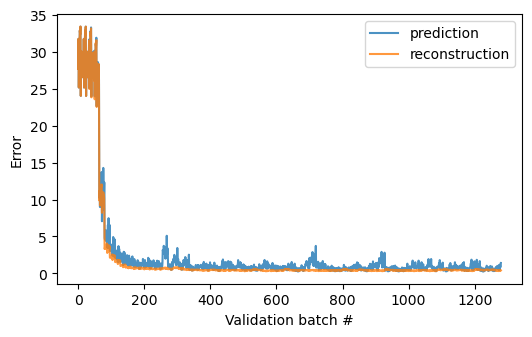

In [4]:
# ---------------------------------------------------------------------------*/
# - training and validation

batch_size = config['batch_size']

# make validation datasets and loaders
dataset_valid = torch.utils.data.TensorDataset(data_valid)
dataloader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size=batch_size, shuffle=False)

# specify optimizer and a loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# specify the length of our validated prediction
prediction_steps_n = timeseries_len

err_train_recon = []
err_train_pred = []
err_train_mode = []

err_valid_recon = []
err_valid_pred = []

datafiles_train_n = 4#random.randint(4, 6)
print(f"inf >> Number of data files for training : {datafiles_train_n}")

for datafile_train in range(datafiles_train_n):
    print(f"inf >> Processing training file number {datafile_train + 1}")
    data_train = utils.read_datafile(f'{dataset_dir}/train{datafile_train + 1}', timeseries_len)

    # make training datasets and loaders
    dataset_train = torch.utils.data.TensorDataset(data_train)
    dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

    # train
    for epoch in range(20):

        # train neural networks
        for data in dataloader_train:
            timeseries = data[0] # data are a batch of timeseries

            optimizer.zero_grad()

            loss, err_recon, err_pred, err_mode = model.fit(timeseries)
            loss.backward()

            optimizer.step()

            with torch.no_grad():
                err_train_recon.append(err_recon)
                err_train_pred.append(err_pred)
                err_train_mode.append(err_mode)

        # validate results
        with torch.no_grad():
            for data in dataloader_valid:
                timeseries = data[0] # data are a batch of timeseries

                # validate prediction
                horizon_valid = config['horizon']
                timeseries_pred = model.predict(timeseries, horizon_valid)
                err_valid_pred.append(torch.mean((timeseries[:, :horizon_valid, :] - timeseries_pred)**2))

                # validate reconstruction
                timeseries_recon = model.reconstructor(model.decomposer(timeseries))
                err_valid_recon.append(torch.mean((timeseries - timeseries_recon)**2))

with torch.no_grad():
    plt.figure(figsize=(6, 3.5))
    plt.plot(err_train_pred, alpha=0.8, label='prediction')
    plt.plot(err_train_recon, alpha=0.8, label='reconstruction')
    plt.plot(err_train_mode, alpha=0.8, label='mode')
    plt.xlabel("Training batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 3.5))
    plt.plot(err_valid_pred, alpha=0.8, label='prediction')
    plt.plot(err_valid_recon, alpha=0.8, label='reconstruction')
    plt.xlabel("Validation batch #")
    plt.ylabel("Error")
    plt.legend()
    plt.show()

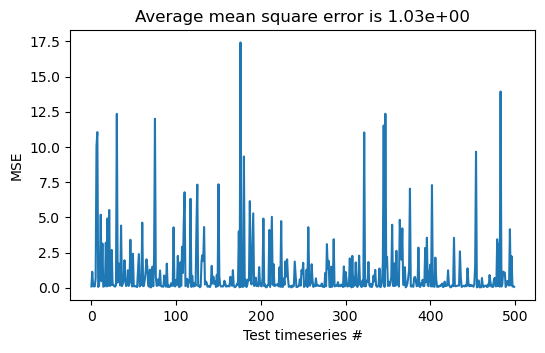

In [5]:
# ---------------------------------------------------------------------------*/
# - test results : check prediction on test data

mse_test_pred = []

for timeseries in data_test:
    horizon_test = config['horizon']
    timeseries_pred = torch.squeeze(model.predict(torch.unsqueeze(timeseries, dim=0), config['horizon']))
    mse_test_pred.append(torch.mean((timeseries[:horizon_test, :] - timeseries_pred)**2))

with torch.no_grad():
    avg_mse_test_pred = np.mean(mse_test_pred)

    plt.figure(figsize=(6, 3.5))
    plt.title(f"Average mean square error is {avg_mse_test_pred:.2e}")
    plt.plot(mse_test_pred)
    plt.xlabel("Test timeseries #")
    plt.ylabel("MSE")
    plt.show()

inf >> Eigenvalue scaling ranges from -0.06 to 0.00
inf >> Eigenvalue frequency ranges from 0.41 to 0.94


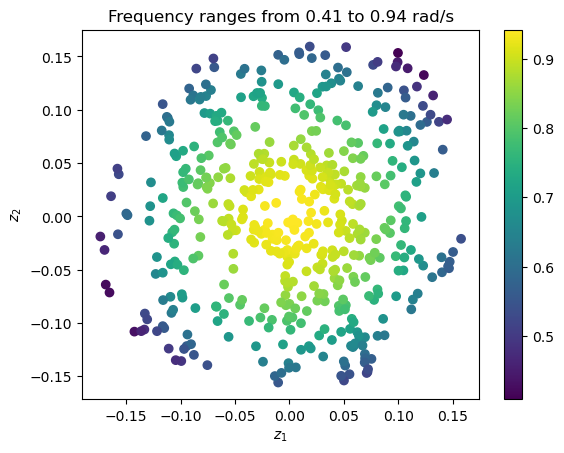

inf >> Eigenvalue scaling ranges from -0.21 to -0.01
inf >> Eigenvalue frequency ranges from 4.12 to 9.90


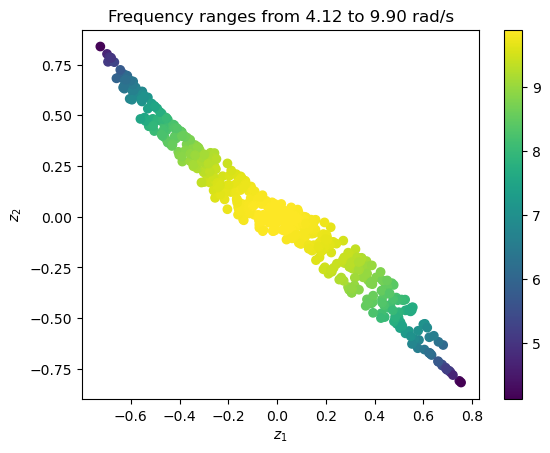

In [6]:
# ---------------------------------------------------------------------------*/
# - test results : check the distribution of frequencies in eigenfunctions

with torch.no_grad():
    eigenfuncs = model.decomposer(model.start_of(data_test))
    eigenvalues = model.dynamics(eigenfuncs)

    eigenfuncs = torch.squeeze(eigenfuncs, 1)
    eigenvalues = torch.squeeze(eigenvalues, 1)

    osc_eigenfuncs_n = int(eigenfuncs.shape[1]/len(config['modes']))
    osc_eigenvalues_n = int(eigenvalues.shape[1]/len(config['modes']))

    # split eigenfunctions and eigenvalues per oscillator to facilitate their analysis and displaying
    osc_eigenfuncs = torch.split(eigenfuncs.T, osc_eigenfuncs_n, dim=0)
    osc_eigenvalues = torch.split(eigenvalues.T, osc_eigenvalues_n, dim=0)

    osc_i = range(len(config['modes']))

    for eigenfunc, eigenvalue, i in zip(osc_eigenfuncs, osc_eigenvalues, osc_i):

        eva_e_min = torch.min(eigenvalue[0, :])
        eva_e_max = torch.max(eigenvalue[0, :])
        print(f"inf >> Eigenvalue scaling ranges from {eva_e_min:.2f} to {eva_e_max:.2f}")

        eva_f_min = torch.min(eigenvalue[1, :])
        eva_f_max = torch.max(eigenvalue[1, :])
        print(f"inf >> Eigenvalue frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f}")

        plt.figure()
        plt.scatter(eigenfunc[0, :], eigenfunc[1, :], c=eigenvalue[1, :])
        plt.title(f'Frequency ranges from {eva_f_min:.2f} to {eva_f_max:.2f} rad/s')
        plt.xlabel('$z_1$')
        plt.ylabel('$z_2$')
        plt.colorbar()
        #plt.savefig(f'fig/pendulum/play_dmd_10rad_efn_ic_by_freq_{i}.svg')
        plt.show()


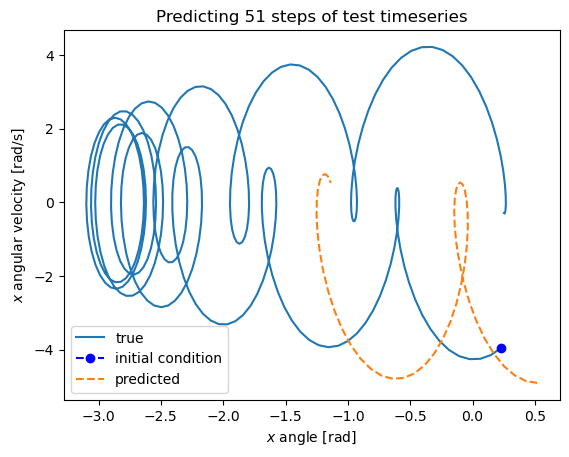

In [10]:
with torch.no_grad():
    data_test_i = 444
    test_horizon = 51
    timeseries = data_test[torch.newaxis, data_test_i]
    timeseries_pred = model.predict(timeseries, test_horizon)

    plt.figure()
    plt.title(f'Predicting {test_horizon} steps of test timeseries')
    plt.plot(timeseries[0, :, 0], timeseries[0, :, 1], label='true')
    plt.plot(timeseries[0, 0, 0], timeseries[0, 0, 1], '--bo', label='initial condition')
    plt.plot(timeseries_pred[0, :, 0], timeseries_pred[0, :, 1], linestyle='dashed', label='predicted')
    plt.legend()
    plt.xlabel("$x$ angle [rad]")
    plt.ylabel("$x$ angular velocity [rad/s]")
    #plt.savefig(f'fig/pendulum/play_dmd_ts_pred_1rad_10rad_{data_test_i}.svg')
    plt.show()